In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/synthetic_transactions.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"DATASET OVERVIEW")
print(f"{'='*50}")
print(f"Total transactions: {len(df):,}")
print(f"Cardholders: {df['cardholder_id'].nunique():,}")
print(f"Date range: {df['timestamp'].min().date()} to {df['timestamp'].max().date()}")
print(f"Merchants: {df['merchant_name'].nunique()}")
print(f"Categories: {df['merchant_category'].nunique()}")
print(f"Cities: {df['merchant_city'].nunique()}")
print(f"Countries: {df['merchant_country'].nunique()}")
print(f"\nFraud breakdown:")
print(f"  Legitimate: {len(df[df['is_fraud']==0]):,} ({len(df[df['is_fraud']==0])/len(df)*100:.2f}%)")
print(f"  Fraudulent: {len(df[df['is_fraud']==1]):,} ({len(df[df['is_fraud']==1])/len(df)*100:.3f}%)")
print(f"\nFraud types:")
print(df[df['is_fraud']==1]['fraud_type'].value_counts().to_string())
print(f"\nColumns:")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

DATASET OVERVIEW
Total transactions: 500,000
Cardholders: 5,000
Date range: 2024-01-01 to 2024-06-28
Merchants: 104
Categories: 15
Cities: 24
Countries: 3

Fraud breakdown:
  Legitimate: 497,912 (99.58%)
  Fraudulent: 2,088 (0.418%)

Fraud types:
fraud_type
bust_out            1316
account_takeover     278
card_testing         250
cnp_fraud            151
geo_impossible        93

Columns:
  transaction_id: object
  cardholder_id: object
  timestamp: datetime64[ns]
  merchant_name: object
  merchant_category: object
  mcc: int64
  merchant_city: object
  merchant_state: object
  merchant_country: object
  amount: float64
  currency: object
  is_online: bool
  is_recurring: bool
  is_international: bool
  is_fraud: int64
  fraud_type: object


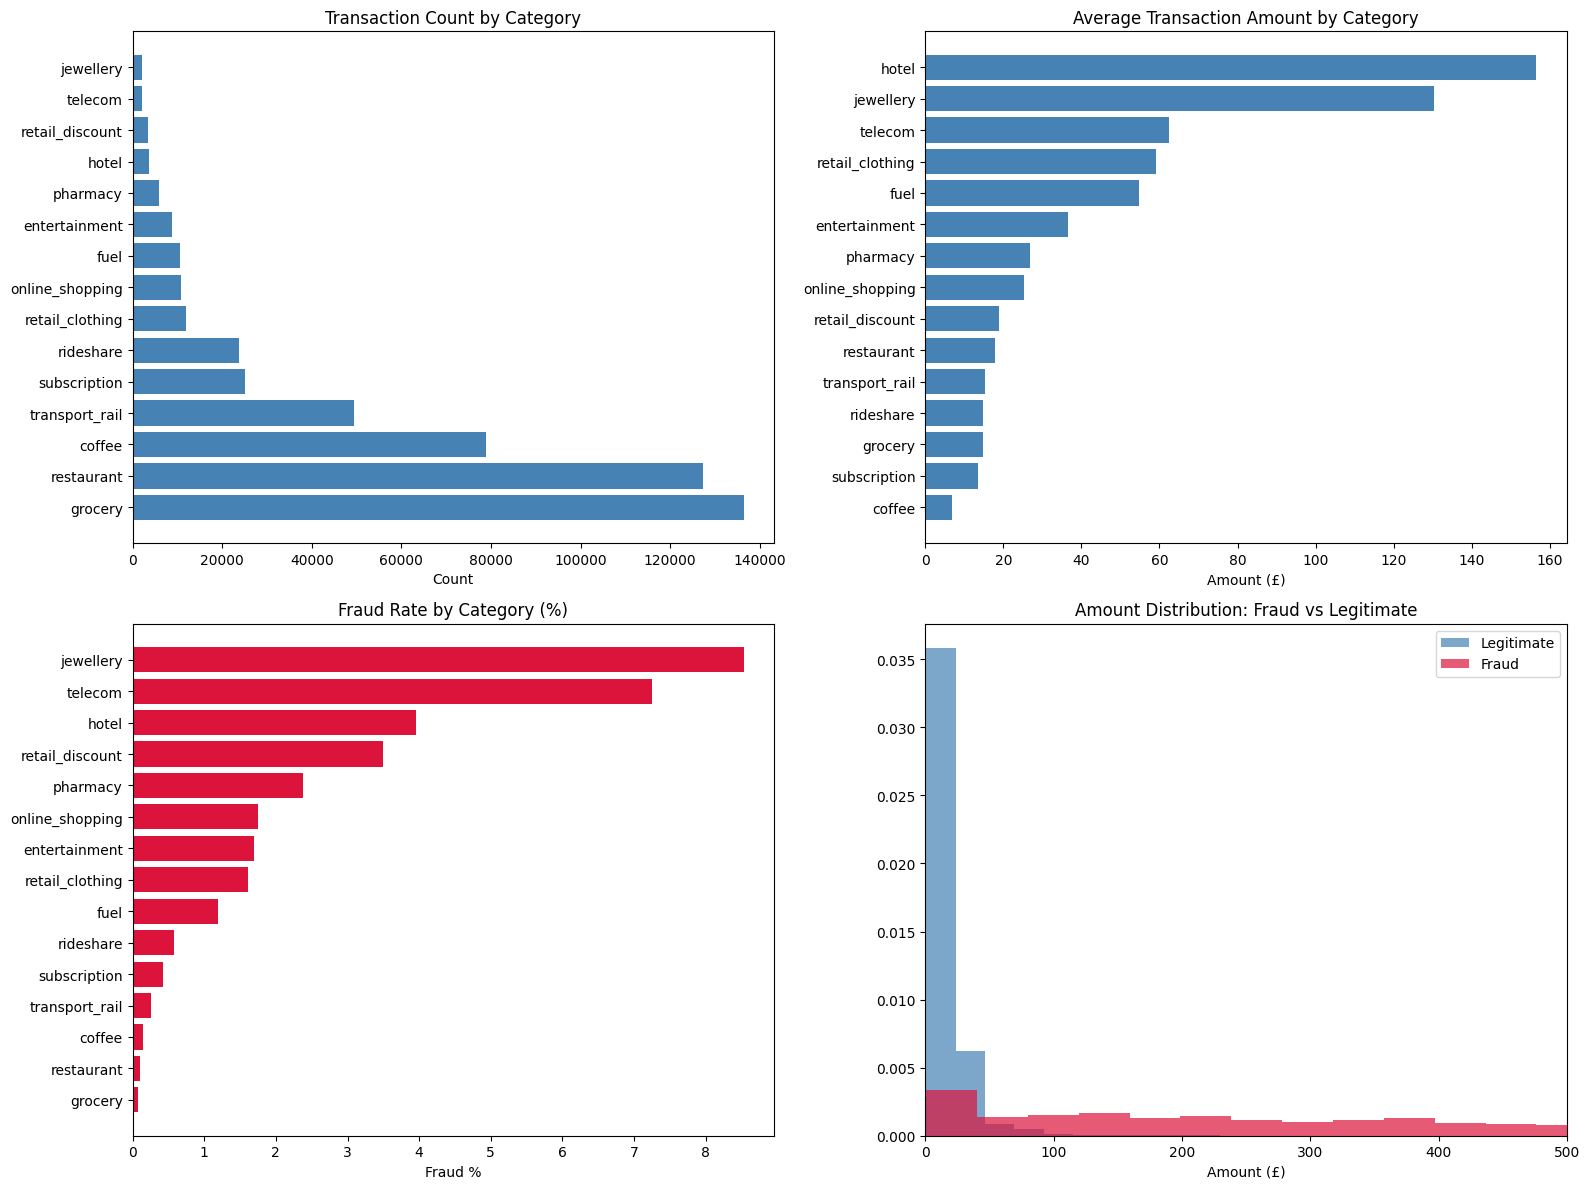

AMOUNT STATISTICS

Legitimate:
count    497912.00
mean         16.87
std          20.24
min           0.75
25%           7.26
50%          11.98
75%          19.62
max        1144.09
Name: amount, dtype: float64

Fraudulent:
count    2088.00
mean      434.43
std       439.38
min         0.51
25%       120.04
50%       307.32
75%       587.78
max      1983.01
Name: amount, dtype: float64


In [3]:
# SPENDING BY CATEGORY
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Transaction count by category
cat_counts = df['merchant_category'].value_counts()
axes[0,0].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[0,0].set_title('Transaction Count by Category')
axes[0,0].set_xlabel('Count')

# 2. Average amount by category
cat_amounts = df.groupby('merchant_category')['amount'].mean().sort_values(ascending=True)
colors = ['crimson' if cat in df[df['is_fraud']==1]['merchant_category'].values else 'steelblue' for cat in cat_amounts.index]
axes[0,1].barh(cat_amounts.index, cat_amounts.values, color='steelblue')
axes[0,1].set_title('Average Transaction Amount by Category')
axes[0,1].set_xlabel('Amount (£)')

# 3. Fraud rate by category
fraud_by_cat = df.groupby('merchant_category')['is_fraud'].mean() * 100
fraud_by_cat = fraud_by_cat.sort_values(ascending=True)
axes[1,0].barh(fraud_by_cat.index, fraud_by_cat.values, color='crimson')
axes[1,0].set_title('Fraud Rate by Category (%)')
axes[1,0].set_xlabel('Fraud %')

# 4. Amount distribution — fraud vs legitimate
axes[1,1].hist(df[df['is_fraud']==0]['amount'], bins=50, alpha=0.7, label='Legitimate', color='steelblue', density=True)
axes[1,1].hist(df[df['is_fraud']==1]['amount'], bins=50, alpha=0.7, label='Fraud', color='crimson', density=True)
axes[1,1].set_title('Amount Distribution: Fraud vs Legitimate')
axes[1,1].set_xlabel('Amount (£)')
axes[1,1].set_xlim(0, 500)
axes[1,1].legend()

plt.tight_layout()
plt.show()

print("AMOUNT STATISTICS")
print(f"\nLegitimate:")
print(df[df['is_fraud']==0]['amount'].describe().round(2))
print(f"\nFraudulent:")
print(df[df['is_fraud']==1]['amount'].describe().round(2))

/var/folders/mq/vrcy8r_12fl7xdnmnj12cxbm0000gn/T/ipykernel_64142/2819184286.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,0].boxplot(type_data, labels=fraud_types, vert=True)
/var/folders/mq/vrcy8r_12fl7xdnmnj12cxbm0000gn/T/ipykernel_64142/2819184286.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fraud['hour'] = fraud['timestamp'].dt.hour


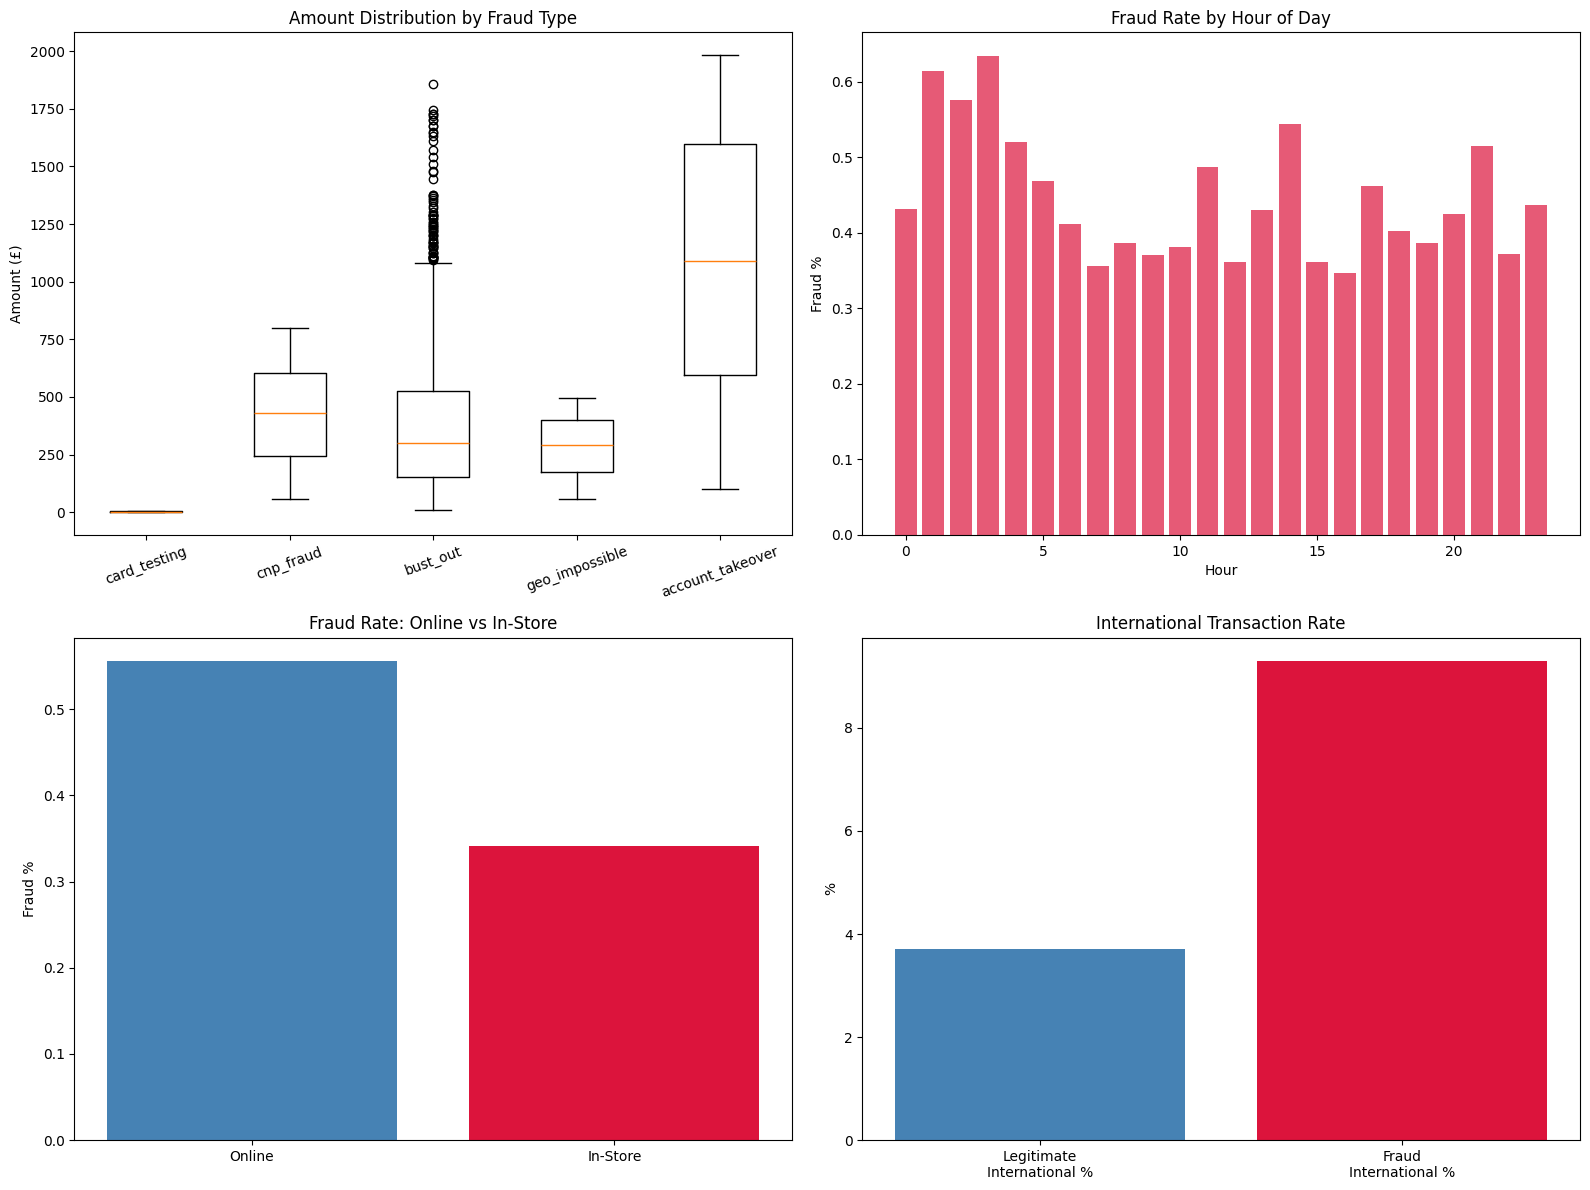

FRAUD PATTERN ANALYSIS

CARD_TESTING (250 transactions)
  Avg amount: £2.75
  Online: 55%
  International: 0%
  Top categories: telecom, retail_clothing, retail_discount
  Top cities: London, Brighton, Manchester

CNP_FRAUD (151 transactions)
  Avg amount: £427.79
  Online: 100%
  International: 100%
  Top categories: online_shopping, jewellery, entertainment
  Top cities: New York, San Francisco, Washington

BUST_OUT (1316 transactions)
  Avg amount: £391.04
  Online: 39%
  International: 0%
  Top categories: rideshare, transport_rail, pharmacy
  Top cities: London, Brighton, Manchester

GEO_IMPOSSIBLE (93 transactions)
  Avg amount: £284.14
  Online: 0%
  International: 46%
  Top categories: restaurant, retail_clothing, online_shopping
  Top cities: London, Brighton, New York

ACCOUNT_TAKEOVER (278 transactions)
  Avg amount: £1081.96
  Online: 70%
  International: 0%
  Top categories: hotel, pharmacy, telecom
  Top cities: London, Brighton, Birmingham


In [4]:
# DEEP DIVE INTO FRAUD PATTERNS
fraud = df[df['is_fraud'] == 1]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Amount by fraud type
fraud_types = fraud['fraud_type'].unique()
type_data = [fraud[fraud['fraud_type']==ft]['amount'].values for ft in fraud_types]
axes[0,0].boxplot(type_data, labels=fraud_types, vert=True)
axes[0,0].set_title('Amount Distribution by Fraud Type')
axes[0,0].set_ylabel('Amount (£)')
axes[0,0].tick_params(axis='x', rotation=20)

# 2. Fraud by hour of day
fraud['hour'] = fraud['timestamp'].dt.hour
legit = df[df['is_fraud'] == 0].copy()
legit['hour'] = legit['timestamp'].dt.hour

fraud_by_hour = fraud['hour'].value_counts().sort_index()
legit_by_hour = legit['hour'].value_counts().sort_index()
fraud_rate_by_hour = (fraud_by_hour / (fraud_by_hour + legit_by_hour) * 100).fillna(0)

axes[0,1].bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values, color='crimson', alpha=0.7)
axes[0,1].set_title('Fraud Rate by Hour of Day')
axes[0,1].set_xlabel('Hour')
axes[0,1].set_ylabel('Fraud %')

# 3. Online vs offline fraud
online_fraud = fraud['is_online'].value_counts()
online_legit = legit['is_online'].value_counts()
fraud_rate_online = pd.DataFrame({
    'Online': [fraud[fraud['is_online']==True].shape[0] / df[df['is_online']==True].shape[0] * 100],
    'In-Store': [fraud[fraud['is_online']==False].shape[0] / df[df['is_online']==False].shape[0] * 100],
})
axes[1,0].bar(fraud_rate_online.columns, fraud_rate_online.values[0], color=['steelblue', 'crimson'])
axes[1,0].set_title('Fraud Rate: Online vs In-Store')
axes[1,0].set_ylabel('Fraud %')

# 4. International vs domestic fraud
intl_fraud_rate = fraud['is_international'].mean() * 100
intl_legit_rate = legit['is_international'].mean() * 100
axes[1,1].bar(['Legitimate\nInternational %', 'Fraud\nInternational %'],
              [intl_legit_rate, intl_fraud_rate], color=['steelblue', 'crimson'])
axes[1,1].set_title('International Transaction Rate')
axes[1,1].set_ylabel('%')

plt.tight_layout()
plt.show()

# Print key stats
print("FRAUD PATTERN ANALYSIS")
print(f"{'='*50}")
for ft in fraud_types:
    ft_data = fraud[fraud['fraud_type'] == ft]
    print(f"\n{ft.upper()} ({len(ft_data)} transactions)")
    print(f"  Avg amount: £{ft_data['amount'].mean():.2f}")
    print(f"  Online: {ft_data['is_online'].mean()*100:.0f}%")
    print(f"  International: {ft_data['is_international'].mean()*100:.0f}%")
    print(f"  Top categories: {', '.join(ft_data['merchant_category'].value_counts().head(3).index.tolist())}")
    print(f"  Top cities: {', '.join(ft_data['merchant_city'].value_counts().head(3).index.tolist())}")

In [5]:
# CARDHOLDER BEHAVIOR — this is what Kaggle couldn't give us
ch_stats = df.groupby('cardholder_id').agg(
    total_txns=('amount', 'count'),
    total_spend=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    unique_merchants=('merchant_name', 'nunique'),
    unique_categories=('merchant_category', 'nunique'),
    unique_cities=('merchant_city', 'nunique'),
    online_pct=('is_online', 'mean'),
    international_pct=('is_international', 'mean'),
    has_fraud=('is_fraud', 'max'),
).reset_index()

print("CARDHOLDER PROFILES")
print(f"{'='*50}")
print(f"\nClean cardholders: {len(ch_stats[ch_stats['has_fraud']==0]):,}")
print(f"Compromised cardholders: {len(ch_stats[ch_stats['has_fraud']==1]):,}")

print(f"\nAvg transactions per cardholder: {ch_stats['total_txns'].mean():.0f}")
print(f"Avg spend per cardholder: £{ch_stats['total_spend'].mean():.2f}")
print(f"Avg unique merchants: {ch_stats['unique_merchants'].mean():.1f}")
print(f"Avg unique categories: {ch_stats['unique_categories'].mean():.1f}")

print(f"\nCOMPROMISED vs CLEAN cardholders:")
print(f"{'Metric':<25} {'Clean':<15} {'Compromised':<15}")
print(f"{'-'*55}")
for metric in ['total_txns', 'total_spend', 'avg_amount', 'max_amount', 'unique_categories', 'unique_cities']:
    clean = ch_stats[ch_stats['has_fraud']==0][metric].mean()
    fraud = ch_stats[ch_stats['has_fraud']==1][metric].mean()
    print(f"{metric:<25} {clean:<15.2f} {fraud:<15.2f}")

CARDHOLDER PROFILES

Clean cardholders: 4,585
Compromised cardholders: 415

Avg transactions per cardholder: 100
Avg spend per cardholder: £1861.13
Avg unique merchants: 40.5
Avg unique categories: 8.9

COMPROMISED vs CLEAN cardholders:
Metric                    Clean           Compromised    
-------------------------------------------------------
total_txns                99.49           105.61         
total_spend               1678.26         3881.56        
avg_amount                17.03           36.20          
max_amount                129.87          645.44         
unique_categories         8.72            10.33          
unique_cities             11.94           12.23          


In [6]:
# FEATURES YOU CAN ONLY BUILD WITH REAL-STRUCTURED DATA
# This is what makes this dataset worth 10x more than Kaggle

# Sort by cardholder and time
df = df.sort_values(['cardholder_id', 'timestamp']).reset_index(drop=True)

# Per-cardholder rolling features
print("ENGINEERING CARDHOLDER-LEVEL FEATURES")
print("These were IMPOSSIBLE with Kaggle's anonymized V1-V28")
print(f"{'='*60}")

# Example: one cardholder's transaction history
sample_ch = df[df['cardholder_id'] == df['cardholder_id'].iloc[0]].head(15)

print(f"\nSample cardholder: {sample_ch['cardholder_id'].iloc[0]}")
print(f"{'Date':<22} {'Merchant':<20} {'Category':<18} {'Amount':>8} {'City':<15}")
print(f"{'-'*85}")
for _, row in sample_ch.iterrows():
    print(f"{str(row['timestamp']):<22} {row['merchant_name'][:18]:<20} {row['merchant_category'][:16]:<18} £{row['amount']:>7.2f} {row['merchant_city']:<15}")

# Now show what features we can compute
print(f"\n\nFEATURES WE CAN NOW ENGINEER:")
print(f"{'='*60}")

features = [
    ("amount_vs_personal_avg", "Is this amount unusual FOR THIS CARDHOLDER? (not global avg)"),
    ("time_since_last_txn", "Seconds since their last transaction (rapid = suspicious)"),
    ("category_frequency", "How often does this cardholder use this category?"),
    ("new_merchant_flag", "First time at this merchant? New merchants are riskier"),
    ("new_city_flag", "First time in this city? Geographic novelty = risk signal"),
    ("daily_txn_count", "How many transactions today? Unusual velocity = fraud"),
    ("daily_spend", "Total spend today vs their daily average"),
    ("online_ratio_shift", "Sudden shift from in-store to online = account takeover"),
    ("category_deviation", "Spending in unusual categories vs their normal pattern"),
    ("international_flag", "International when cardholder is normally domestic"),
    ("amount_acceleration", "Is spending ramping up? Bust-out pattern"),
    ("merchant_category_risk", "Risk score based on fraud rate in this category"),
    ("geo_velocity", "Distance between last two transactions / time = impossible travel?"),
    ("weekend_vs_weekday", "Is this transaction on an unusual day for this cardholder?"),
    ("recurring_break", "Missed a recurring payment? Account may be compromised"),
]

for name, desc in features:
    print(f"\n  {name}")
    print(f"    {desc}")

print(f"\n\nWith Kaggle: 11 engineered features from anonymous data")
print(f"With this dataset: {len(features)}+ features from real transaction structure")
print(f"This is why real-structured data matters for production fraud detection.")

ENGINEERING CARDHOLDER-LEVEL FEATURES
These were IMPOSSIBLE with Kaggle's anonymized V1-V28

Sample cardholder: CH-0004D0B5
Date                   Merchant             Category             Amount City           
-------------------------------------------------------------------------------------
2024-01-03 17:23:26    CityMart             grocery            £  10.73 Edinburgh      
2024-01-04 08:18:53    Chicken Shack        restaurant         £  22.60 Manchester     
2024-01-06 11:22:36    Metro Transit        transport_rail     £  25.27 Manchester     
2024-01-06 17:00:12    Daily Basket         grocery            £  11.72 London         
2024-01-08 09:52:30    InterCity Lines      transport_rail     £   6.42 Brighton       
2024-01-11 07:12:33    Daily Grind          coffee             £  12.00 London         
2024-01-11 12:32:31    Curry Corner         restaurant         £  10.53 Brighton       
2024-01-11 15:41:51    Metro Transit        transport_rail     £  19.12 Manchester    

In [7]:
# Random 50 rows from the dataset
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 20)

sample = df.sample(50, random_state=123).sort_values('timestamp')

print(f"50 RANDOM TRANSACTIONS")
print(f"{'='*120}")
for _, r in sample.iterrows():
    fraud_flag = " *** FRAUD ***" if r['is_fraud'] == 1 else ""
    online = "ONLINE" if r['is_online'] else "STORE "
    intl = "INTL" if r['is_international'] else "    "
    print(f"{str(r['timestamp'])[:16]}  {r['cardholder_id']}  {r['merchant_name']:<20} {r['merchant_category']:<18} £{r['amount']:>8.2f}  {online}  {intl}  {r['merchant_city']:<15} {r['merchant_country']}{fraud_flag}")

50 RANDOM TRANSACTIONS
2024-01-04 21:38  CH-E243AA93  Fresh Market         grocery            £   28.56  STORE         London          GB
2024-01-06 11:15  CH-CA4B3353  DigitalMart          online_shopping    £    8.59  ONLINE        London          GB
2024-01-09 10:17  CH-272E1170  Wrap It Up           restaurant         £    6.18  STORE         Brighton        GB
2024-01-12 10:06  CH-82EDC5C9  Metro Foods          grocery            £    7.91  STORE   INTL  New York        US
2024-01-15 10:54  CH-D38EE19A  Morning Brew         coffee             £    6.52  STORE         London          GB
2024-01-24 15:53  CH-CA8155F4  Steam & Sip          coffee             £    2.50  STORE         Birmingham      GB
2024-01-25 09:06  CH-B6617980  ZipRide              rideshare          £    6.84  ONLINE        Brighton        GB
2024-01-25 19:38  CH-BB073F28  Burger Central       restaurant         £    6.14  STORE         Edinburgh       GB
2024-01-29 07:25  CH-F7696A9B  Fish & Co            resta